In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
# I uploaded the customer segmentation dataset to Google Colab.
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
# Load the uploaded CSV file
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# I selected Annual Income and Spending Score for customer segmentation.
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Display the selected features
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


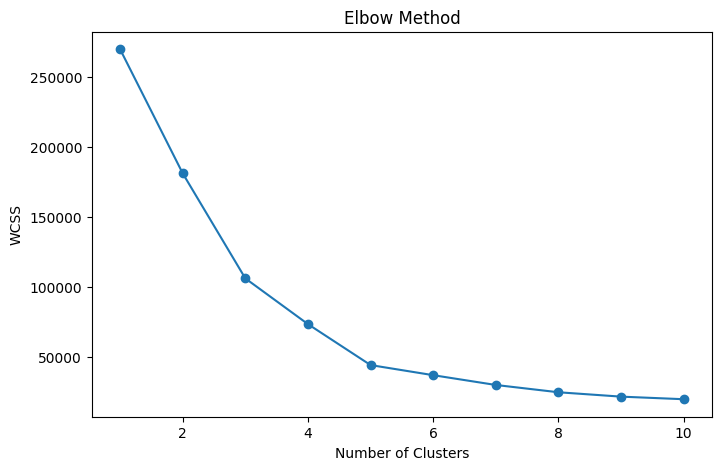

In [5]:
# Calculate WCSS for different values of K
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [6]:
# I chose 5 clusters based on the elbow graph.
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model and predict cluster labels
df["Cluster"] = kmeans.fit_predict(X)

In [7]:
# Show the first 20 customers with their assigned clusters
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


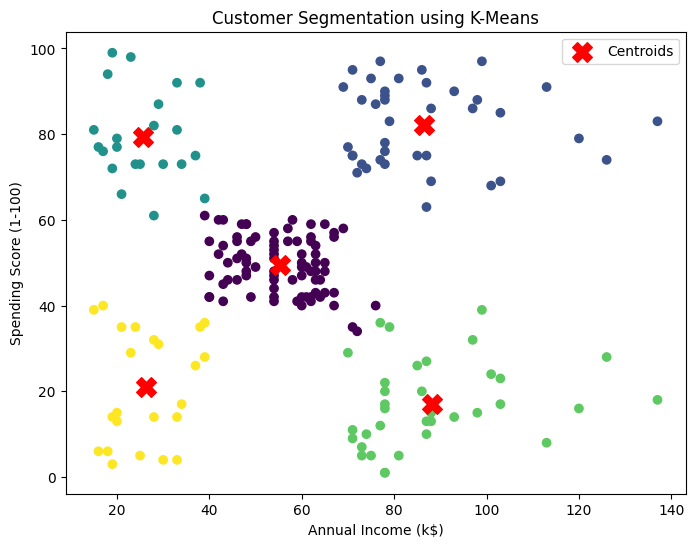

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [9]:
# Create a table showing customer information and assigned cluster
comparison = df[[
    "CustomerID",
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]]

comparison.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [10]:
# Save the clustered dataset as a CSV file
comparison.to_csv("Customer_Segments.csv", index=False)

print("Customer segmentation completed successfully!")

Customer segmentation completed successfully!
